# Homework 5

**Before you start:** Read Chapter on Naive Bayes and KNN in the textbook.

**Note:** Please enter the code along with your comments in the **TODO** section.

Alternative solutions are always welcomed.

# Part 1: K-Nearst-Neighbors

### Problem 2 ##

The objective is to classify the breast cancer data using K-NN classifier.

**TODO1**

Load the breast cancer data and rename the columns to the below fields in the same order

Id, C_thickness, Cell_Size, Cell_Shape, Adhesion, E_Cell_Size, Bare_Nuclei, B_Chromatin, N_Nucleoli, Mitoses, Class

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score

In [42]:
df1 = pd.read_csv("breast-cancer-wisconsin.txt",header=None)
df1.head(2)

,0,1,2,3,4,5,6,7,8,9,10
0,0,1,2,3,4,5,6,7,8,9,10
1,1000025,5,1,1,1,2,1,3,1,1,2


In [43]:
df1.rename(columns={
    0: 'ID',
    1: 'C_thickness',
    2: 'Cell_Size',
    3: 'Cell_Shape',
    4: 'Adhesion',
    5: 'E_Cell_Size',
    6: 'Bare_Nuclei',
    7: 'B_Chromatin',
    8: 'N_Nucleoli',
    9: 'Mitoses',
    10: 'Classes'
}, inplace=True)

df1.head(2)

,ID,C_thickness,Cell_Size,Cell_Shape,Adhesion,E_Cell_Size,Bare_Nuclei,B_Chromatin,N_Nucleoli,Mitoses,Classes
0,0,1,2,3,4,5,6,7,8,9,10
1,1000025,5,1,1,1,2,1,3,1,1,2


In [44]:
df1.isna().sum()

ID             0
C_thickness    0
Cell_Size      0
Cell_Shape     0
Adhesion       0
E_Cell_Size    0
Bare_Nuclei    0
B_Chromatin    0
N_Nucleoli     0
Mitoses        0
Classes        0
dtype: int64

In [45]:
df1.shape

(700, 11)

**TODO 2**

Plot the heatmap for the correlation coefficients with the target variable (Class)  and interpret your findings.


Drop redundant columns and view summary of the dataset.
Convert all the variables to numeric.


In [46]:
df1.dtypes

ID              int64
C_thickness     int64
Cell_Size       int64
Cell_Shape      int64
Adhesion        int64
E_Cell_Size     int64
Bare_Nuclei    object
B_Chromatin     int64
N_Nucleoli      int64
Mitoses         int64
Classes         int64
dtype: object

In [47]:
df1['Bare_Nuclei'] = pd.to_numeric(df1['Bare_Nuclei'], errors='coerce')
df1['Bare_Nuclei'] = df1['Bare_Nuclei'].fillna(df1['Bare_Nuclei'].mean())
df1['Bare_Nuclei'].isna().sum()

0

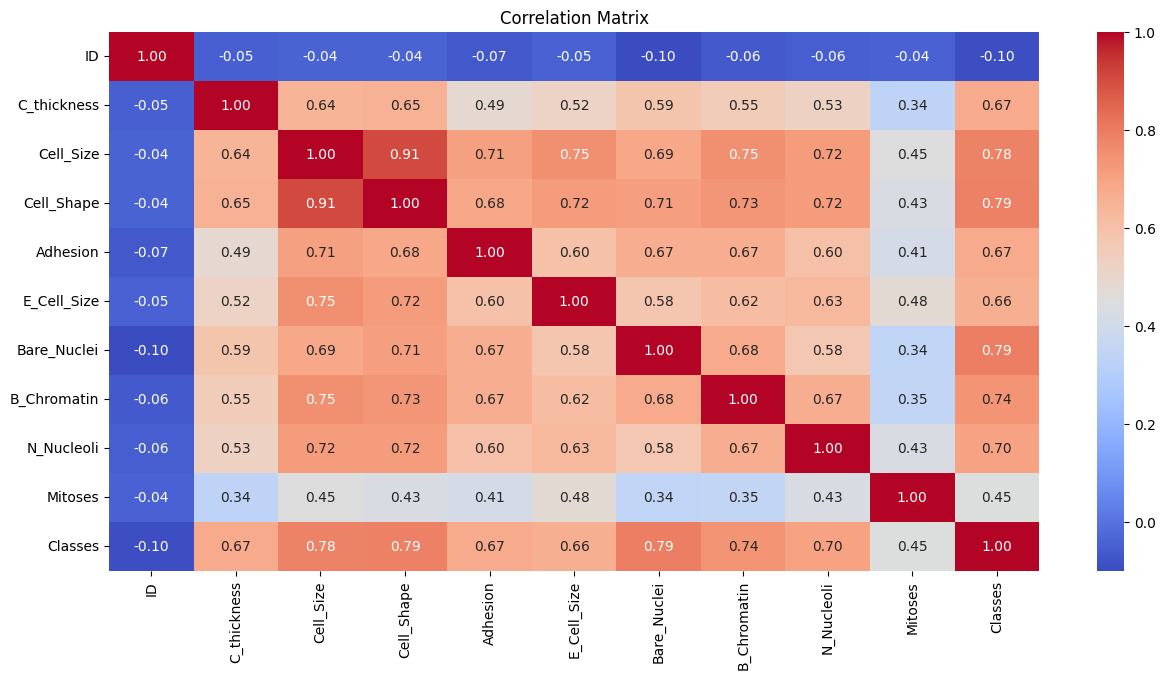

In [48]:
correlation_matrix = df1.corr()
plt.figure(figsize=(15,7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**TODO 3**



Considering the fundamental idea of k-NN, would you recommend data rescaling before model building? Why?

If so, partition the data into 75% training and 25% validation set.

Impute the missing values with the mean values of training data.
Check if all the nulls are removed in both train and test dataset.

Standardize the data.

**Note:**   When you standardize the validation set, you need to use the training set's mean and variance.


Data Rescaling is a distance based Algo so Data Rescaling would be required in order to provide us with non biased results.

In [49]:
df1.shape

(700, 11)

In [52]:
test_size = 0.25
X = df1.drop(['ID', 'Classes'], axis=1)
y = df1['Classes']

def scaling(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return pd.DataFrame(X_scaled, columns=X.columns)
X_scaled = scaling(X)
X_scaled.head(2)

,C_thickness,Cell_Size,Cell_Shape,Adhesion,E_Cell_Size,Bare_Nuclei,B_Chromatin,N_Nucleoli,Mitoses
0,-1.212522,-0.371746,-0.069800,0.417803,0.805289,0.681441,1.458687,1.677578,4.264277
1,0.208600,-0.699895,-0.743728,-0.634219,-0.550851,-0.708260,-0.181604,-0.613429,-0.345752


In [53]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)

In [54]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (525, 9)
X_test shape: (175, 9)
y_train shape: (525,)
y_test shape: (175,)


In [55]:
print(f"X_train missing : {X_train.isna().sum()}")
print(f"X_test missing : {X_test.isna().sum()}")
print(f"y_train missing : {y_train.isna().sum()}")
print(f"y_test missing : {y_test.isna().sum()}")

X_train missing : C_thickness    0
Cell_Size      0
Cell_Shape     0
Adhesion       0
E_Cell_Size    0
Bare_Nuclei    0
B_Chromatin    0
N_Nucleoli     0
Mitoses        0
dtype: int64
X_test missing : C_thickness    0
Cell_Size      0
Cell_Shape     0
Adhesion       0
E_Cell_Size    0
Bare_Nuclei    0
B_Chromatin    0
N_Nucleoli     0
Mitoses        0
dtype: int64
y_train missing : 0
y_test missing : 0


**TODO 4**

Choose the best k from 1-10 based on the classification accuracy of different k values on the validation set.

In [60]:
barsetter = range(1,11)
for x in barsetter:
    model = KNeighborsClassifier(n_neighbors=x,n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for K={x} is {acc}")
    
     


Accuracy for K=1 is 0.9542857142857143
Accuracy for K=2 is 0.9428571428571428
Accuracy for K=3 is 0.9714285714285714
Accuracy for K=4 is 0.96
Accuracy for K=5 is 0.9714285714285714
Accuracy for K=6 is 0.96
Accuracy for K=7 is 0.9714285714285714
Accuracy for K=8 is 0.9714285714285714
Accuracy for K=9 is 0.9771428571428571
Accuracy for K=10 is 0.9771428571428571


**TODO 5**

For the chosen k, display the confusion matrix and evaluate the performance of the model using recall and precision.

Check for overfitting and underfitting for the k chosen.

Accuracy for both k = 9,10 is the same as per K-NN Model so we will use k = 10 for the problem

In [63]:
model1 = KNeighborsClassifier(n_neighbors=10,n_jobs=-1)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print("Model 1 Accuracy:", accuracy_score(y_test, y_pred1))
print("Model 1 Precision:", precision_score(y_test, y_pred1,pos_label=4))
print("Model 1 Recall:", recall_score(y_test, y_pred1,pos_label=4))
print("Model 1 F1 Score:", f1_score(y_test, y_pred1,pos_label=4))



Model 1 Accuracy: 0.9771428571428571
Model 1 Precision: 0.953125
Model 1 Recall: 0.9838709677419355
Model 1 F1 Score: 0.9682539682539683


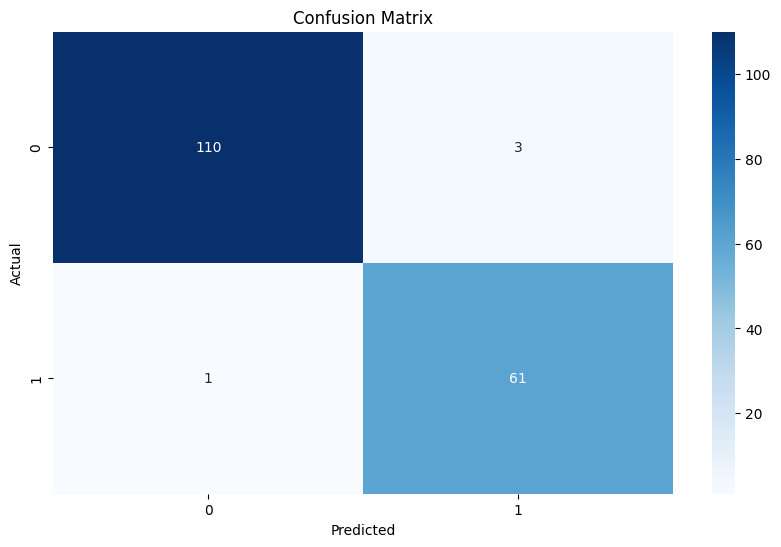

In [64]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**TODO 6**

Classify the new record given below using the chosen k.

1002945, 5, 4, 4, 5, 7, 10, 3, 2, 1

In [65]:
new_record = [[5, 4, 4, 5, 7, 10, 3, 2, 1]]
new_record_scaled = scaling(pd.DataFrame(new_record, columns=X.columns))
new_prediction = model1.predict(new_record_scaled)

print("Predicted Class for the new record:", new_prediction[0])

Predicted Class for the new record: 2


### Problem 3 ##

The data concerns city-cycle fuel consumption in miles per gallon (mpg). The objective is to use k-NN regression to predict the mpg with the given attributes.

In [66]:
df2 = pd.read_csv("auto_mpg.csv")
df2.head(2)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320


**TODO 1**

Check the unique value of the variable "car name".

Would you recommend keeping "car name" for prediction? Why?

If not, eliminate the variable "car name".

In [67]:
df2['car name'].unique()

array(['chevrolet chevelle malibu', 'buick skylark 320',
       'plymouth satellite', 'amc rebel sst', 'ford torino',
       'ford galaxie 500', 'chevrolet impala', 'plymouth fury iii',
       'pontiac catalina', 'amc ambassador dpl', 'dodge challenger se',
       "plymouth 'cuda 340", 'chevrolet monte carlo',
       'buick estate wagon (sw)', 'toyota corona mark ii',
       'plymouth duster', 'amc hornet', 'ford maverick', 'datsun pl510',
       'volkswagen 1131 deluxe sedan', 'peugeot 504', 'audi 100 ls',
       'saab 99e', 'bmw 2002', 'amc gremlin', 'ford f250', 'chevy c20',
       'dodge d200', 'hi 1200d', 'chevrolet vega 2300', 'toyota corona',
       'plymouth satellite custom', 'ford torino 500', 'amc matador',
       'pontiac catalina brougham', 'dodge monaco (sw)',
       'ford country squire (sw)', 'pontiac safari (sw)',
       'amc hornet sportabout (sw)', 'chevrolet vega (sw)',
       'pontiac firebird', 'ford mustang', 'mercury capri 2000',
       'opel 1900', 'peugeot 304

Since Car Names is a categoricla column which will not provide various insights for model building we drop that column

In [69]:
df2 = df2.drop(['car name'], axis=1)

In [70]:
df2.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1


**TODO 2**

Convert the variable "origin" to dummy variables before modeling

In [68]:
df2['origin'].value_counts()

origin
1    246
3     79
2     68
Name: count, dtype: int64

In [72]:
df2 = pd.concat([df2, pd.get_dummies(df2['origin'], prefix='origin', drop_first=True)], axis=1)
df2 = df2.drop(columns=['origin'])
df2.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130,3504,12.0,70,False,False
1,15.0,8,350.0,165,3693,11.5,70,False,False


**TODO 3**

Rescale the numeric data. Note that dummy variables should not be rescaled.

**Note:** When you standardize the validation set, you need to use the training set's mean and variance.

In [74]:
df2.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin_2           bool
origin_3           bool
dtype: object

In [76]:
df2['horsepower'] = pd.to_numeric(df2['horsepower'], errors='coerce')
df2['horsepower'] = df2['horsepower'].fillna(df2['horsepower'].mean())
df2['horsepower'].isna().sum()

0

In [77]:
X = df2.drop(['mpg','origin_2','origin_3'], axis=1)
y = df2['mpg']
def scaling(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_new = scaling(X)
X_scaled_new.head(2)

,cylinders,displacement,horsepower,weight,acceleration,model year
0,1.484867,1.078523,0.664979,0.621628,-1.287786,-1.625418
1,1.484867,1.490488,1.576602,0.844701,-1.469418,-1.625418


**TODO 4**

Partition the data into 75% training and 25% validation set.

In [78]:
test_size = 0.25
X_train, X_test, y_train, y_test = train_test_split(X_scaled_new, y, test_size=test_size, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_train missing : {X_train.isna().sum()}")
print(f"X_test missing : {X_test.isna().sum()}")
print(f"y_train missing : {y_train.isna().sum()}")
print(f"y_test missing : {y_test.isna().sum()}")

X_train shape: (294, 6)
X_test shape: (99, 6)
y_train shape: (294,)
y_test shape: (99,)
X_train missing : cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
dtype: int64
X_test missing : cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
dtype: int64
y_train missing : 0
y_test missing : 0


**TODO 5**

Choose the best k from 1-10 based on the MSE of different k values on the validation set. Explain the reason for your choice.

In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor

In [82]:
barsetter = range(1,11)
for x in barsetter:
    model = KNeighborsRegressor(n_neighbors=x,n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error for K={x} is {mse}")

Mean Squared Error for K=1 is 15.513232323232327
Mean Squared Error for K=2 is 12.395
Mean Squared Error for K=3 is 12.002906846240176
Mean Squared Error for K=4 is 12.269273989898991
Mean Squared Error for K=5 is 12.860626262626262
Mean Squared Error for K=6 is 12.603445566778898
Mean Squared Error for K=7 is 13.605433931148221
Mean Squared Error for K=8 is 13.321202651515154
Mean Squared Error for K=9 is 12.959100885397186
Mean Squared Error for K=10 is 13.020900000000005


**TODO 6**


Score the validation set with the best k. Comment on the model performance.

K = 3 produces a model with the least MSE of : 12.00029

In [83]:
model2 = KNeighborsRegressor(n_neighbors=3,n_jobs=-1)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
mse = mean_squared_error(y_test, y_pred2)
mae = mean_absolute_error(y_test, y_pred2)
rmse = np.sqrt(mse)
print(f"Model 2 Mean Squared Error: {mse}")
print(f"Model 2 Mean Absolute Error: {mae}")
print(f"Model 2 Root Mean Squared Error: {rmse}")

Model 2 Mean Squared Error: 12.002906846240176
Model 2 Mean Absolute Error: 2.3626262626262626
Model 2 Root Mean Squared Error: 3.4645211568469567


# Naive Bayes

### **Problem 4**##

In this problem, we need to build a Naive Bayes model to classify whether a movie review is positive or negative.

The given data is a subset of [the IMDB movie review dataset](https://www.kaggle.com/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).

This might be your first time working with text mining. Therefore, the basic pre-processing steps are given below.

**You have two major tasks:**

* Go through the code and get to know the purpose of each preprocessing step. Summarize what a preprocessing step does when required.
* Build a multinomial Naive Bayes model to classify the reviews.

In [ ]:
# # Please remove # and run the following code if you have an error while importing the dataset
# !pip install --upgrade openpyxl

In [84]:
import pandas as pd
df = pd.read_csv("IMDB Dataset_subset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [85]:
# Packages required for preprocessing #
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import WordNetLemmatizer #for lemmatization
import re #regular expression package
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/regata3010/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/regata3010/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [86]:
X = [row for row in df['review']] #list of reviews
classes = df['sentiment'] #list of true classes

In [87]:
# Pre-process the data
reviews = []
lemmatizer = WordNetLemmatizer()

for review in range(0, len(X)):
    # part 1
    review = re.sub(r'[\W_]', ' ', str(X[review]))
    review = re.sub(r'\s+[a-zA-Z]\s+', ' ', review)
    review = re.sub(r'\^[a-zA-Z]\s+', ' ', review)
    review = re.sub(r'\s+', ' ', review, flags=re.I)
    review = re.sub(r'^b\s+', '', review) # if a review record is in bytes, the corresponding line will have a letter 'b' appended at the start)
    review = review.lower()
    review = re.sub(r'[0-9]+', '', review)

    # part 2
    review = review.split()
    review = [lemmatizer.lemmatize(word) for word in review]
    review = ' '.join(review)

    reviews.append(review)


**TODO 1**

Explain the function that part 1 and part 2 achieve in the loop.

The function that is being achieved is called lemmatizing which we perform on text data for various sentiment analysis techniques.
1) You remove all the alphanumeric charactrers first then remove single character surrounded by spaces.
2) Then u remove all the sibgle characters at the start and replace multiple spaces with a single space.
3) Last is converting to lowercase, removing numbers and then we tokenize and lemmatize and append it all to list called "review".

In [88]:
# Continue with pre-processing
vectorizer = CountVectorizer(stop_words = "english", max_df=0.7, min_df=5)
texts = vectorizer.fit_transform(reviews).toarray()
vocab = vectorizer.vocabulary_
vocab = sorted(vocab.items(), key = lambda x: x[1])
vocab = [v[0] for v in vocab]


**TODO 2**

What do "texts" and "vocab" represent? What is the relationship between them?

Texts: This represents the document-term matrix, where each row corresponds to a processed review, and each column corresponds to a unique word (feature) in the vocabulary. The values in the matrix indicate the frequency of each word in the respective review.

Vocab: This is the vocabulary extracted from the reviews, which contains all the unique words that meet the criteria specified in the CountVectorizer (e.g., minimum and maximum document frequency). It is a sorted list of words mapped to their respective indices in the document-term matrix.

Relationship: The vocab defines the columns (features) of the texts matrix. Each word in vocab corresponds to a column in texts, and the values in texts represent the frequency of those words in the reviews.

**TODO 3**

Partition the data into 80% training and 20% validation set.

In [90]:
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(texts, classes, test_size=test_size, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (3200, 8396)
X_test shape: (800, 8396)
y_train shape: (3200,)
y_test shape: (800,)


**TODO 4**

Build a multinomial Naive Bayes model on the training set.

In [96]:
from sklearn.naive_bayes import MultinomialNB

In [97]:
modelnb = MultinomialNB()
modelnb.fit(X_train, y_train)
y_pred_nb = modelnb.predict(X_test)


**Hint:** [Multinomial Naive Bayes with sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)

**TODO 5**

Evaluate the model performance with the training and validation set. Comment on the model performance.

In [98]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


Accuracy: 0.82875


In [99]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))


Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.83      0.83       399
    positive       0.83      0.83      0.83       401

    accuracy                           0.83       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.83      0.83      0.83       800



**Hint:** [Classification report with sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

**If you are interested (this part is not graded):**

Explore one or two records that were misclassified. Check the original text, vectorized text, and comment on the possible reason why the record got misclassified.